In [1]:
!pip uninstall -y transformers huggingface_hub tokenizers accelerate peft torchao adapters adapter-transformers
!pip install -q -U transformers accelerate peft datasets evaluate sentencepiece protobuf scikit-learn tqdm

Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
Found existing installation: huggingface_hub 1.16.1
Uninstalling huggingface_hub-1.16.1:
  Successfully uninstalled huggingface_hub-1.16.1
Found existing installation: tokenizers 0.22.2
Uninstalling tokenizers-0.22.2:
  Successfully uninstalled tokenizers-0.22.2
Found existing installation: accelerate 1.13.0
Uninstalling accelerate-1.13.0:
  Successfully uninstalled accelerate-1.13.0
Found existing installation: peft 0.19.1
Uninstalling peft-0.19.1:
  Successfully uninstalled peft-0.19.1
Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 143.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━

In [2]:
import torch

print("CUDA var mı:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU yok.")

CUDA var mı: True
GPU: NVIDIA A100-SXM4-40GB


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/turkish-news-classification")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [5]:
import os

search_root = "/content/drive/MyDrive/turkish-news-classification"

for root, dirs, files in os.walk(search_root):
    if "interpress_prompt_sample_dataset" in dirs:
        print("Bulundu:", os.path.join(root, "interpress_prompt_sample_dataset"))

Bulundu: /content/drive/MyDrive/turkish-news-classification/notebooks/data/processed/interpress_prompt_sample_dataset


In [6]:
from pathlib import Path
from datasets import load_from_disk

DATASET_PATH = Path("/content/drive/MyDrive/turkish-news-classification/notebooks/data/processed/interpress_prompt_sample_dataset")

dataset = load_from_disk(str(DATASET_PATH))
dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'title_clean', 'content_for_prompt', 'category', 'prompt', 'answer', 'text'],
        num_rows: 8500
    })
    validation: Dataset({
        features: ['id', 'title_clean', 'content_for_prompt', 'category', 'prompt', 'answer', 'text'],
        num_rows: 1700
    })
    test: Dataset({
        features: ['id', 'title_clean', 'content_for_prompt', 'category', 'prompt', 'answer', 'text'],
        num_rows: 1700
    })
})

In [7]:
print(dataset)

print("Train:", len(dataset["train"]))
print("Validation:", len(dataset["validation"]))
print("Test:", len(dataset["test"]))

print(dataset["train"][0].keys())
print(dataset["train"][0]["prompt"][:500])
print("Cevap:", dataset["train"][0]["answer"])

DatasetDict({
    train: Dataset({
        features: ['id', 'title_clean', 'content_for_prompt', 'category', 'prompt', 'answer', 'text'],
        num_rows: 8500
    })
    validation: Dataset({
        features: ['id', 'title_clean', 'content_for_prompt', 'category', 'prompt', 'answer', 'text'],
        num_rows: 1700
    })
    test: Dataset({
        features: ['id', 'title_clean', 'content_for_prompt', 'category', 'prompt', 'answer', 'text'],
        num_rows: 1700
    })
})
Train: 8500
Validation: 1700
Test: 1700
dict_keys(['id', 'title_clean', 'content_for_prompt', 'category', 'prompt', 'answer', 'text'])
Görev: Aşağıdaki Türkçe haberin kategorisini belirle.
Sadece verilen kategorilerden birini yaz.

Kategoriler: aktuel, bilisim, egitim, ekonomi, gida, iletisim, kultursanat, magazin, saglik, savunma, seyahat, siyasi, spor, teknoloji, ticaret, turizm, yasam

Başlık: MANCHESTER'DA YOLLAR BOYANDI
Haber: Manchester da yollar boyandı Premier Lig in son haftasında QPR yi yenerek 44 yıl 

In [8]:
import torch

print("CUDA var mı:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU yok.")

CUDA var mı: True
GPU: NVIDIA A100-SXM4-40GB


In [9]:
import os
import json
import torch
import numpy as np
from pathlib import Path

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq
)

from peft import (
    LoraConfig,
    get_peft_model,
    TaskType
)

In [10]:
PROJECT_ROOT = Path("/content/drive/MyDrive/turkish-news-classification")

RESULTS_DIR = PROJECT_ROOT / "results"
OUTPUT_DIR = RESULTS_DIR / "gemma_e2b_lora_sample_fixed"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output dir:", OUTPUT_DIR)

Output dir: /content/drive/MyDrive/turkish-news-classification/results/gemma_e2b_lora_sample_fixed


In [12]:
MODEL_NAME = "google/gemma-4-E2B-it"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

model.config.pad_token_id = tokenizer.pad_token_id

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/4.95k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.10k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/17.3k [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/10.2G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1951 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

In [13]:
from peft import (
    LoraConfig,
    get_peft_model,
    TaskType
)

In [15]:
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules="all-linear",
    bias="none"
)

model = get_peft_model(model, lora_config)

model.print_trainable_parameters()

trainable params: 37,920,768 || all params: 5,142,218,272 || trainable%: 0.7374


In [16]:
MAX_LENGTH = 1024

def tokenize_function(example):
    prompt = example["prompt"]
    answer = " " + example["answer"] + tokenizer.eos_token

    answer_tokens = tokenizer(
        answer,
        add_special_tokens=False
    )

    max_prompt_length = MAX_LENGTH - len(answer_tokens["input_ids"])

    if max_prompt_length < 1:
        max_prompt_length = MAX_LENGTH - 10

    prompt_tokens = tokenizer(
        prompt,
        truncation=True,
        max_length=max_prompt_length,
        padding=False,
        add_special_tokens=False
    )

    input_ids = prompt_tokens["input_ids"] + answer_tokens["input_ids"]
    attention_mask = [1] * len(input_ids)

    labels = [-100] * len(prompt_tokens["input_ids"]) + answer_tokens["input_ids"]

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels
    }

In [17]:
tokenized_dataset = dataset.map(
    tokenize_function,
    remove_columns=dataset["train"].column_names
)

tokenized_dataset

Map:   0%|          | 0/8500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1700 [00:00<?, ? examples/s]

Map:   0%|          | 0/1700 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 8500
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 1700
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 1700
    })
})

In [18]:
def count_supervised_tokens(example):
    return sum(1 for x in example["labels"] if x != -100)

train_supervised = [
    count_supervised_tokens(tokenized_dataset["train"][i])
    for i in range(len(tokenized_dataset["train"]))
]

val_supervised = [
    count_supervised_tokens(tokenized_dataset["validation"][i])
    for i in range(len(tokenized_dataset["validation"]))
]

print("Train min supervised tokens:", min(train_supervised))
print("Validation min supervised tokens:", min(val_supervised))

print("Train sıfır supervised:", sum(1 for x in train_supervised if x == 0))
print("Validation sıfır supervised:", sum(1 for x in val_supervised if x == 0))

Train min supervised tokens: 2
Validation min supervised tokens: 2
Train sıfır supervised: 0
Validation sıfır supervised: 0


In [19]:
print(tokenized_dataset["train"][0].keys())
print("Input length:", len(tokenized_dataset["train"][0]["input_ids"]))
print("Label length:", len(tokenized_dataset["train"][0]["labels"]))

dict_keys(['input_ids', 'attention_mask', 'labels'])
Input length: 167
Label length: 167


In [20]:
import os
import json
import torch
import numpy as np
from pathlib import Path

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq
)

from peft import (
    LoraConfig,
    get_peft_model,
    TaskType
)

In [21]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True
)

In [22]:
training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),

    num_train_epochs=1,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=16,

    learning_rate=2e-4,
    weight_decay=0.01,
    warmup_ratio=0.03,

    logging_steps=20,
    eval_strategy="steps",
    eval_steps=100,
    save_steps=100,
    save_total_limit=2,

    fp16=True,

    report_to="none",
    remove_unused_columns=False
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [23]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=data_collator,
)

In [24]:
trainer.train()

Step,Training Loss,Validation Loss
100,0.677362,0.689875
200,0.620337,0.609502
300,0.616409,0.599499
400,0.557608,0.535003
500,0.512869,0.516723
532,0.487463,0.511001


TrainOutput(global_step=532, training_loss=0.7804949946869585, metrics={'train_runtime': 5723.3575, 'train_samples_per_second': 1.485, 'train_steps_per_second': 0.093, 'total_flos': 7.929005872678714e+16, 'train_loss': 0.7804949946869585, 'epoch': 1.0})

In [25]:
FINAL_MODEL_DIR = PROJECT_ROOT / "results" / "gemma_e2b_lora_sample_fixed" / "final_model"

trainer.save_model(str(FINAL_MODEL_DIR))
tokenizer.save_pretrained(str(FINAL_MODEL_DIR))

print("Model kaydedildi:", FINAL_MODEL_DIR)

Model kaydedildi: /content/drive/MyDrive/turkish-news-classification/results/gemma_e2b_lora_sample_fixed/final_model


In [26]:
from pathlib import Path

def get_folder_size_mb(folder_path):
    total_size = 0

    for path in Path(folder_path).rglob("*"):
        if path.is_file():
            total_size += path.stat().st_size

    return total_size / (1024 * 1024)

model_size_mb = get_folder_size_mb(FINAL_MODEL_DIR)

print("Model size MB:", model_size_mb)

Model size MB: 175.5274658203125


In [27]:
def predict_category(title, content, max_new_tokens=8):
    prompt = f"""Görev: Aşağıdaki Türkçe haberin kategorisini belirle.
Sadece verilen kategorilerden birini yaz.

Kategoriler: aktuel, bilisim, egitim, ekonomi, gida, iletisim, kultursanat, magazin, saglik, savunma, seyahat, siyasi, spor, teknoloji, ticaret, turizm, yasam

Başlık: {title}
Haber: {content}

Kategori:"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH
    ).to(model.device)

    input_length = inputs["input_ids"].shape[1]

    model.eval()

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    generated_tokens = outputs[0][input_length:]
    prediction = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    ).strip()

    return prediction

In [28]:
title = "Fenerbahçe derbide galip geldi"
content = "Süper Lig'de oynanan derbi maçında Fenerbahçe rakibini mağlup ederek puanını yükseltti."

predict_category(title, content)

'spor'

In [29]:
eval_results = trainer.evaluate()
eval_results

Training Loss,Validation Loss,Step
0.487463,0.511001,532


{'eval_loss': 0.511001467704773}

In [30]:
import re
import torch
import pandas as pd
import numpy as np
from tqdm import tqdm
from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

In [31]:
import re
import torch

label_names = [
    "aktuel",
    "bilisim",
    "egitim",
    "ekonomi",
    "gida",
    "iletisim",
    "kultursanat",
    "magazin",
    "saglik",
    "savunma",
    "seyahat",
    "siyasi",
    "spor",
    "teknoloji",
    "ticaret",
    "turizm",
    "yasam"
]

def normalize_prediction(text):
    text = text.lower().strip()
    text = re.sub(r"[^a-zçğıöşü\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()

    for label in label_names:
        if label in words:
            return label

    for label in label_names:
        if label in text:
            return label

    return "unknown"


MAX_LENGTH = 1024

def predict_from_prompt(prompt, max_new_tokens=8):
    model.eval()

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH
    ).to(model.device)

    input_length = inputs["input_ids"].shape[1]

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    generated_tokens = outputs[0][input_length:]

    raw_prediction = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    ).strip()

    clean_prediction = normalize_prediction(raw_prediction)

    return clean_prediction, raw_prediction

In [32]:
for i in range(10):
    prompt = dataset["test"][i]["prompt"]
    true_label = dataset["test"][i]["answer"]

    pred_label, raw_pred = predict_from_prompt(prompt)

    print("Gerçek:", true_label)
    print("Tahmin:", pred_label)
    print("Ham çıktı:", raw_pred)
    print("-" * 50)

Gerçek: ticaret
Tahmin: kultursanat
Ham çıktı: kultursanat
--------------------------------------------------
Gerçek: bilisim
Tahmin: bilisim
Ham çıktı: bilisim
--------------------------------------------------
Gerçek: bilisim
Tahmin: bilisim
Ham çıktı: bilisim
--------------------------------------------------
Gerçek: ekonomi
Tahmin: ekonomi
Ham çıktı: ekonomi
--------------------------------------------------
Gerçek: teknoloji
Tahmin: savunma
Ham çıktı: savunma
--------------------------------------------------
Gerçek: teknoloji
Tahmin: bilisim
Ham çıktı: bilisim
--------------------------------------------------
Gerçek: teknoloji
Tahmin: teknoloji
Ham çıktı: teknoloji
--------------------------------------------------
Gerçek: ekonomi
Tahmin: ekonomi
Ham çıktı: ekonomi
--------------------------------------------------
Gerçek: spor
Tahmin: spor
Ham çıktı: spor
--------------------------------------------------
Gerçek: ekonomi
Tahmin: yasam
Ham çıktı: yasam
--------------------------

In [33]:
from tqdm import tqdm

In [34]:
y_true = []
y_pred = []
raw_outputs = []
titles = []
contents = []

for example in tqdm(dataset["test"]):
    prompt = example["prompt"]
    true_label = example["answer"]

    pred_label, raw_pred = predict_from_prompt(prompt)

    y_true.append(true_label)
    y_pred.append(pred_label)
    raw_outputs.append(raw_pred)
    titles.append(example["title_clean"])
    contents.append(example["content_for_prompt"])

100%|██████████| 1700/1700 [13:26<00:00,  2.11it/s]


In [35]:
unknown_count = sum(1 for p in y_pred if p == "unknown")

print("Unknown tahmin sayısı:", unknown_count)
print("Toplam test sayısı:", len(y_pred))
print("Unknown oranı:", unknown_count / len(y_pred))

Unknown tahmin sayısı: 4
Toplam test sayısı: 1700
Unknown oranı: 0.002352941176470588


In [36]:
accuracy = accuracy_score(y_true, y_pred)

precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=label_names,
    average="macro",
    zero_division=0
)

precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=label_names,
    average="weighted",
    zero_division=0
)

print("Accuracy:", accuracy)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1:", f1_macro)
print("Weighted Precision:", precision_weighted)
print("Weighted Recall:", recall_weighted)
print("Weighted F1:", f1_weighted)

Accuracy: 0.518235294117647
Macro Precision: 0.48836821090957144
Macro Recall: 0.5182352941176471
Macro F1: 0.4922794605515629
Weighted Precision: 0.48836821090957133
Weighted Recall: 0.518235294117647
Weighted F1: 0.492279460551563


In [37]:
report = classification_report(
    y_true,
    y_pred,
    labels=label_names,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

      aktuel       0.07      0.02      0.03       100
     bilisim       0.54      0.59      0.56       100
      egitim       0.65      0.45      0.53       100
     ekonomi       0.40      0.45      0.42       100
        gida       0.67      0.75      0.71       100
    iletisim       0.50      0.47      0.48       100
 kultursanat       0.54      0.68      0.60       100
     magazin       0.50      0.58      0.54       100
      saglik       0.58      0.66      0.62       100
     savunma       0.90      0.92      0.91       100
     seyahat       0.62      0.60      0.61       100
      siyasi       0.33      0.12      0.18       100
        spor       0.67      0.89      0.76       100
   teknoloji       0.47      0.54      0.50       100
     ticaret       0.31      0.59      0.41       100
      turizm       0.41      0.46      0.43       100
       yasam       0.13      0.04      0.06       100

   micro avg       0.52   

In [38]:
results_df = pd.DataFrame({
    "true_label": y_true,
    "pred_label": y_pred,
    "raw_output": raw_outputs,
    "title": titles,
    "content": contents
})

results_df.head()

,true_label,pred_label,raw_output,title,content
0,ticaret,kultursanat,kultursanat,DÜNYA 'MEVLANA DİYARI'NDA BULUŞACAK,Dünya Mevtana diyarı nda buluşacak Türk ve İsl...
1,bilisim,bilisim,bilisim,AVERMEDİA LGP LİTE,AVerMedia LGP Lite ;raşanlar ve oyuncular HSC ...
2,bilisim,bilisim,bilisim,FERRARİS İVME SENSÖRÜ,ACC 93 . ACC 94 Ferraris İvme Sensörü ? ürün v...
3,ekonomi,ekonomi,ekonomi,KARŞILIKSIZ ÇEKTE TUTAR 27 MİLYARI GEÇTİ,Karşılıksız çekte tutar 27 milyarı geçti HABER...
4,teknoloji,savunma,savunma,FERRİTİK BİR ÇELİKTE KOROZYON İNCELEMELERİ,Ferritik Bir Çelikte Korozyon İncelemeleri İ E...


In [39]:
PROJECT_ROOT = Path("/content/drive/MyDrive/turkish-news-classification")

RESULTS_DIR = PROJECT_ROOT / "results"
OUTPUT_DIR = RESULTS_DIR / "qwen25_15b_lora_sample_fixed"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output dir:", OUTPUT_DIR)

Output dir: /content/drive/MyDrive/turkish-news-classification/results/qwen25_15b_lora_sample_fixed


In [40]:
import time
import numpy as np

sample_for_speed = dataset["test"].select(range(100))

start_time = time.time()

for example in sample_for_speed:
    _ = predict_from_prompt(example["prompt"])

end_time = time.time()

total_time = end_time - start_time
inference_ms_per_sample = (total_time / len(sample_for_speed)) * 1000

print("Toplam süre:", total_time)
print("Inference ms/örnek:", inference_ms_per_sample)

Toplam süre: 46.24652123451233
Inference ms/örnek: 462.4652123451233


In [42]:
metrics = {
    "model": "Gemma-4-E2B",
    "dataset": "interpress_prompt_sample_dataset",
    "train_size": len(dataset["train"]),
    "validation_size": len(dataset["validation"]),
    "test_size": len(dataset["test"]),
    "eval_loss": eval_results["eval_loss"],
    "accuracy": accuracy,
    "macro_precision": precision_macro,
    "macro_recall": recall_macro,
    "macro_f1": f1_macro,
    "weighted_precision": precision_weighted,
    "weighted_recall": recall_weighted,
    "weighted_f1": f1_weighted,
    "unknown_count": unknown_count,
    "inference_ms_per_sample": inference_ms_per_sample,
    "model_size_mb": model_size_mb
}

import json

with open(OUTPUT_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=4)

metrics

{'model': 'Gemma-4-E2B',
 'dataset': 'interpress_prompt_sample_dataset',
 'train_size': 8500,
 'validation_size': 1700,
 'test_size': 1700,
 'eval_loss': 0.511001467704773,
 'accuracy': 0.518235294117647,
 'macro_precision': 0.48836821090957144,
 'macro_recall': 0.5182352941176471,
 'macro_f1': 0.4922794605515629,
 'weighted_precision': 0.48836821090957133,
 'weighted_recall': 0.518235294117647,
 'weighted_f1': 0.492279460551563,
 'unknown_count': 4,
 'inference_ms_per_sample': 462.4652123451233,
 'model_size_mb': 175.5274658203125}

In [43]:
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=label_names
)

cm_df = pd.DataFrame(
    cm,
    index=label_names,
    columns=label_names
)

cm_df

,aktuel,bilisim,egitim,ekonomi,gida,iletisim,kultursanat,magazin,saglik,savunma,seyahat,siyasi,spor,teknoloji,ticaret,turizm,yasam
aktuel,2,0,2,6,3,5,7,16,6,2,4,7,8,4,20,2,5
bilisim,2,59,1,4,0,5,1,1,0,2,1,0,0,24,0,0,0
egitim,2,0,45,3,2,11,7,8,5,0,2,0,1,4,6,2,1
ekonomi,0,7,0,45,0,3,1,1,3,1,0,4,2,2,17,9,5
gida,1,1,0,3,75,1,1,0,1,0,3,0,0,1,0,12,0
iletisim,1,7,11,12,2,47,3,2,2,1,3,0,0,4,0,4,1
kultursanat,0,0,1,4,0,1,68,5,1,0,1,2,2,5,5,3,1
magazin,2,0,0,1,1,1,7,58,6,0,2,0,3,0,6,13,0
saglik,3,0,1,1,4,3,4,3,66,0,3,1,0,4,4,2,1
savunma,1,4,0,1,0,1,0,1,0,92,0,0,0,0,0,0,0


In [44]:
cm_df.to_csv(
    OUTPUT_DIR / "confusion_matrix.csv",
    encoding="utf-8"
)

print("Confusion matrix kaydedildi.")

Confusion matrix kaydedildi.


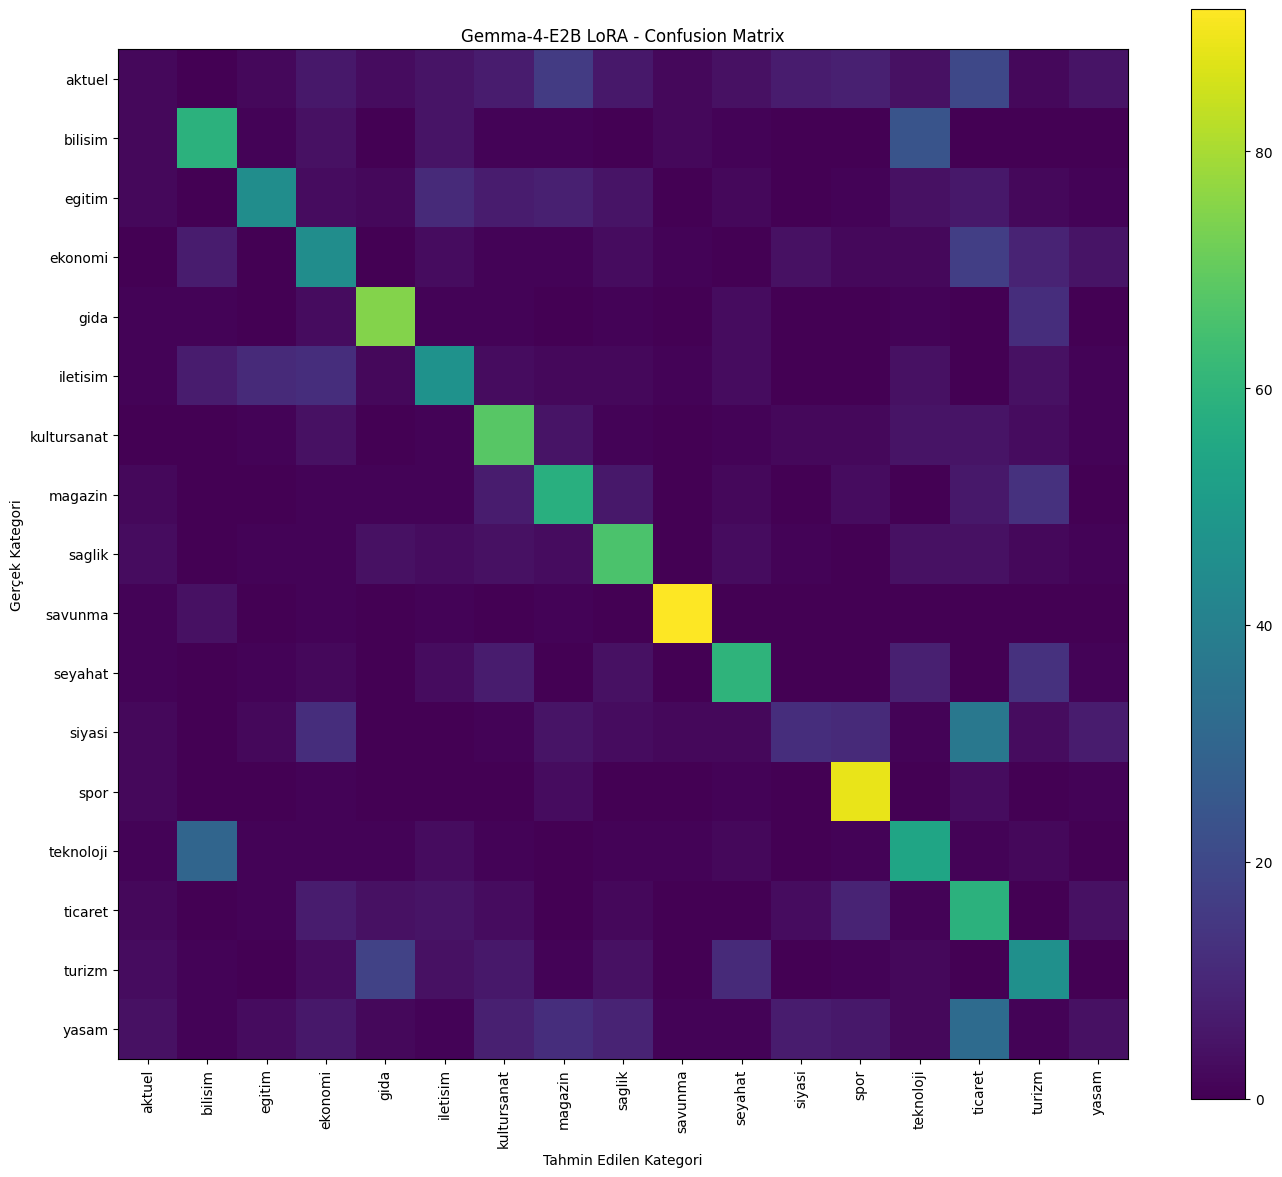

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 12))
plt.imshow(cm, interpolation="nearest")
plt.title("Gemma-4-E2B LoRA - Confusion Matrix")
plt.xticks(np.arange(len(label_names)), label_names, rotation=90)
plt.yticks(np.arange(len(label_names)), label_names)
plt.colorbar()
plt.xlabel("Tahmin Edilen Kategori")
plt.ylabel("Gerçek Kategori")
plt.tight_layout()
plt.show()

In [46]:
confusions = []

for i, true_label in enumerate(label_names):
    for j, pred_label in enumerate(label_names):
        if i != j and cm[i, j] > 0:
            confusions.append({
                "true_label": true_label,
                "pred_label": pred_label,
                "count": cm[i, j]
            })

confusions_df = pd.DataFrame(confusions).sort_values("count", ascending=False)

confusions_df.head(20)

,true_label,pred_label,count
130,siyasi,ticaret,37
188,yasam,ticaret,32
140,teknoloji,bilisim,30
23,bilisim,teknoloji,24
12,aktuel,ticaret,20
166,turizm,gida,18
46,ekonomi,ticaret,17
5,aktuel,magazin,16
118,seyahat,turizm,13
92,magazin,turizm,13


In [47]:
confusions_df.to_csv(
    OUTPUT_DIR / "top_confusions.csv",
    index=False,
    encoding="utf-8"
)

print("En çok karışan kategoriler kaydedildi.")

En çok karışan kategoriler kaydedildi.


In [48]:
error_df = results_df[results_df["true_label"] != results_df["pred_label"]].copy()

print("Yanlış tahmin sayısı:", len(error_df))

error_df.head(10)

Yanlış tahmin sayısı: 819


,true_label,pred_label,raw_output,title,content
0,ticaret,kultursanat,kultursanat,DÜNYA 'MEVLANA DİYARI'NDA BULUŞACAK,Dünya Mevtana diyarı nda buluşacak Türk ve İsl...
4,teknoloji,savunma,savunma,FERRİTİK BİR ÇELİKTE KOROZYON İNCELEMELERİ,Ferritik Bir Çelikte Korozyon İncelemeleri İ E...
5,teknoloji,bilisim,bilisim,"GOOGLE, MAİL ŞİFRELEME SİSTEMİNİ AÇIK KAYNAK T...","Google, mail şifreleme sistemini açık kaynak t..."
9,ekonomi,yasam,yasam,ALTINDAĞLI KADINLAR MOBİLYA USTALARINA TAŞ ÇIK...,24 farklı mahallede hizmete açılan Kadınlar Eğ...
10,yasam,kultursanat,kultursanat,ATIK METALLERİN SANATA DÖNÜŞÜM Ü,ATIK METALLERİN SANATA DÖNÜŞÜM Ü Uçak ve araba...
11,spor,seyahat,seyahat,BALIK VE OLTA,"Balık ve Olta Balık türleri, av malzemeleri, t..."
12,egitim,iletisim,iletisim,REKLAMCILAR ANADOLU'DA BULUŞTU,Reklamcılar Anadolu da buluştu ? İletişim Bili...
18,siyasi,spor,spor,GÜZEL SONUÇLARA İMZA ATACAĞIZ,Güzel sonuçlara imza atacağız Gelecek sezon Tr...
21,aktuel,teknoloji,teknoloji,LAMBA YERİNE BİTKİ,"Bilim insanlarının yaptığı yenilikçi deneyler,..."
23,aktuel,teknoloji,teknoloji,GÖZTEPE OTO SANAYİ SİTESİ ESNAFINI ZOR GÜNLER ...,Göztepe Oto Sanayi Sitesi esnafını zor günler ...


In [49]:
error_examples = error_df.head(5)

for idx, row in error_examples.iterrows():
    print("Gerçek:", row["true_label"])
    print("Tahmin:", row["pred_label"])
    print("Ham çıktı:", row["raw_output"])
    print("Başlık:", row["title"])
    print("İçerik:", row["content"][:500])
    print("-" * 100)

Gerçek: ticaret
Tahmin: kultursanat
Ham çıktı: kultursanat
Başlık: DÜNYA 'MEVLANA DİYARI'NDA BULUŞACAK
İçerik: Dünya Mevtana diyarı nda buluşacak Türk ve İslam dünyasının en büyük mutasavvıflarından Mevlana Celaleddin-i Rumi, 743 üncü vuslat yıl dönümünde yurt içi ve yurt dışından farklı din ve kültürden insanları 7-1 7 Aralık ta Konya da buluşturacak. ÖĞRETİLERİ ile tüm dünyada ilgi uyandıran düşünce adamı, mutasavvıf Mevlana Celaleddin-i Rumi, vefatının 743 üncü yılında düzenlenecek törenlerle anılacak. Her yıl 7-17 Aralık tarihlerinde düzenlenen Mevlana nın Vuslat Yıl Dönümü Uluslararası Anma Törenler
----------------------------------------------------------------------------------------------------
Gerçek: teknoloji
Tahmin: savunma
Ham çıktı: savunma
Başlık: FERRİTİK BİR ÇELİKTE KOROZYON İNCELEMELERİ
İçerik: Ferritik Bir Çelikte Korozyon İncelemeleri İ Elektrolitik nikel ile kaplanmış bir çelikte, ağırlıkça % 3.5 NaCl içeren bir ortamda korozyon oluşumu ve ilerlemesinin mikroskobi